# Reinforcement Learning - Breakout

This notebook trains an AI agent to play the classic Atari game Breakout using **Reinforcement Learning (RL)**.

The agent learns entirely through trial and error, it receives a reward for hitting bricks and losing a life gives a negative outcome. Over millions of game frames, it figures out on its own how to move the paddle to keep the ball alive and maximize its score.

### What's used:
- **Gymnasium** -> provides the Breakout game environment
- **Stable Baselines3** -> provides the PPO algorithm
- **ALE (Arcade Learning Environment)** -> the backend that runs Atari games
- **PyTorch** -> the deep learning framework the model runs on

### Algorithm: PPO (Proximal Policy Optimization)
PPO is a RL algorithm that trains a neural network (the "policy") to decide what action to take given the current game frame. It works by:
1. Playing the game and collecting experience
2. Using that experience to update the policy
3. Clipping updates so the policy doesn't change too drastically at once (this
   keeps training stable)

The model takes raw game pixels as input and outputs an action (move left, move right, stay still).

## Installing Dependencies
Run this cell once to install all required libraries.

- **xvfb** - a virtual display server for Linux, required to render the game visually in Colab (which has no screen)
- **gymnasium[atari]** - the Atari game environments
- **stable-baselines3** - pre-built RL algorithms including PPO
- **ale-py** - the Arcade Learning Environment Python bindings
- **pyvirtualdisplay** - Python wrapper for xvfb
- **imageio / imageio-ffmpeg** - for saving gameplay as GIFs/videos
- **gradio** - for building an interactive demo UI

In [2]:
! apt-get install -y xvfb
! pip install gymnasium[atari] stable-baselines3 ale-py pyvirtualdisplay imageio imageio-ffmpeg gradio

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.8 MB/s eta 0:00:00


## Imports & Google Drive Setup

Imports all required libraries for the project. Google Drive is mounted so that the trained model can be saved and loaded across sessions. Note that Colab's local storage is wiped every time the runtime disconnects.

> **Note:** This notebook will save training results to your Google Drive. Training on Colab is not recommended due to GPU time limits a pre-trained model is available on the GitHub repo. You can skip the training cell and load the pre-trained model directly instead by putting it into your Google Drive. An additional .py file that saves to same folder as the file is in is also on the Github repo if you want to train the model on your own.

In [11]:
# Project Dependencies
import warnings

# Suppress noisy deprecation warnings from libraries during import
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    import gymnasium as gym
    import numpy as np
    import torch
    import torch.nn as nn
    import torchvision.models as models
    import matplotlib.pyplot as plt
    import imageio
    import gradio as gr
    import ale_py

    from google.colab import drive
    from IPython.display import Image
    from pyvirtualdisplay import Display

    from stable_baselines3 import PPO
    from stable_baselines3.common.env_util import make_atari_env
    from stable_baselines3.common.vec_env import VecFrameStack
    from stable_baselines3.common.env_util import make_vec_env
    from stable_baselines3.common.vec_env import VecVideoRecorder
    from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

    gym.register_envs(ale_py)

print("All dependencies loaded successfully!")
# Mount Google Drive — model will be saved/loaded from here
drive.mount("/content/drive")

All dependencies loaded successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Testing the Breakout Environment

Before training, this section verifies the game environment is working correctly by running it with **random actions** and saving the output as a GIF.

The paddle is not being controlled by any model here. Actions are sampled randomly from the action space (left, right, stay). This is just a quick checkup to confirm rendering and the environment are set up correctly before the training and deployment process

Two steps are needed to render in Colab:
1. Start a virtual display (Colab has no physical screen)
2. Create the environment with `render_mode="rgb_array"` to get raw pixel frames

Run the two following cells to perform this checkup.

In [8]:
display = Display(visible=0, size=(1400, 900))
display.start()
print("Virtual Display Started")

Virtual Display Started


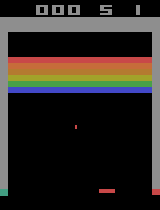

In [9]:
gym.register_envs(ale_py)

# Create the Breakout environment
env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
obs, info = env.reset()

demo_frames = 200
frames = []

for _ in range(demo_frames):
    action = env.action_space.sample() # Pick a random action each step
    obs, _, done, truncated, _ = env.step(action)
    frames.append(obs) # Store the raw pixel frame
    if done or truncated:
        obs, info = env.reset() # Start a new game if this one ended

env.close()

# Saves all captured frames as a GIF and displays it
# duration=30 sets the delay between frames in milliseconds
# if you want to slow down the gif; increase the duration (e.g. duration=60)
# if you want to speed up the gif; decrease the duration (e.g. duration=15)
imageio.mimsave("test_run.gif", frames, duration=30)
Image("test_run.gif", width=400)

## Model Training

This section sets up and trains the PPO agent on Breakout.

### Environment Preprocessing
Raw Atari frames are 210x160 pixels in colour. Before being fed to the model, `make_atari_env` automatically applies standard Atari preprocessing:
- **Grayscale conversion** - reduces 3 colour channels down to 1, reducing
  computation
- **Frame resizing** - scales frames down to 84x84 pixels
- **Frame skipping** - repeats each action for 4 frames and returns the max of
  the last 2 (reduces redundant computation, speeds up training)
- **Frame stacking** - stacks the last 4 frames together so the model can
  perceive motion (a single frame has no motion information)

`n_envs=4` runs 4 copies of the game simultaneously, giving the model more varied experience per update.

### PPO Hyperparameters
- **CnnPolicy** — a built-in convolutional neural network designed for Atari
  pixel input. It processes the stacked frames through conv layers to extract
  spatial features before making action decisions
- **learning_rate=2.5e-4** — how much to adjust the model weights per update.
  Too high = unstable training, too low = very slow learning
- **n_steps=128** — how many game steps each environment collects before an
  update. With 4 envs this means 512 total steps per update
- **batch_size=256** — how many steps are used per gradient update. Larger
  batches are more stable, but use more memory
- **n_epochs=4** — how many times to reuse the collected experience per update.
  More epochs = more efficient use of data, but too many causes instability
- **gamma=0.99** — the discount factor for future rewards. A value close to 1
  means the agent cares about long-term rewards, not just immediate ones
- **total_timesteps=500_000** — total number of game steps to train for.
  Breakout generally needs 3-10M steps to play well. The given model is trained on 2M timesteps, which will show early learning but won't be optimal, as it's just to showcase what it can do.

  On the free version of Google Colab, you can barely run the model to go through 500,000 timesteps, so it's recommended to use the pre-trained model.

In [ ]:
# make_atari_env automatically applies standard Atari preprocessing:
# - grayscale conversion
# - frame resizing (84x84)
# - frame skipping (repeat action for 4 frames)
# n_envs=4 runs 4 parallel game instances to collect more diverse experience
env = make_atari_env("ALE/Breakout-v5", n_envs=4, seed=0)

# Stack the last 4 frames together so the model can detect motion
# (e.g. which direction the ball is moving)
env = VecFrameStack(env, n_stack=4)

model = PPO(
    "CnnPolicy",    # Built-in CNN designed for Atari pixel input
    env,
    learning_rate=2.5e-4, # Step size for weight updates
    n_steps=128, # Steps collected per env before each update
    batch_size=256, # Samples per gradient update
    n_epochs=4, # Times to reuse collected data per update
    gamma=0.99, # Discount factor -> values future rewards highly
    verbose=1, # Print training progress to console
    device="cuda" if torch.cuda.is_available() else "cpu",
)

model.learn(total_timesteps=500_000)

# Save trained model to Google Drive so it persists after runtime disconnects
model.save("/content/drive/MyDrive/breakout_ppo")
print("Training complete!")

Streaming output truncated to the last 5000 lines.
|    value_loss           | 0.00857       |
-------------------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 332           |
|    ep_rew_mean          | 6.28          |
| time/                   |               |
|    fps                  | 72            |
|    iterations           | 686           |
|    time_elapsed         | 4865          |
|    total_timesteps      | 351232        |
| train/                  |               |
|    approx_kl            | 4.5227353e-07 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.012        |
|    explained_variance   | 0.988         |
|    learning_rate        | 0.00025       |
|    loss                 | 0.00659       |
|    n_updates            | 2740          |
|    policy_gradient_loss | -4.29e-06     |
|    value_loss          

KeyboardInterrupt: 

## Loading and Evaluating the Model

This section loads the trained model and records it playing Breakout.

The model runs in **deterministic mode**, meaning it always picks the action it's most confident in rather than sampling probabilistically. This produces cleaner, more consistent gameplay for evaluation.

The environment is reset (new game started) each time a life is lost rather than stopping the recording, so we capture a longer continuous clip. All frames are saved as a GIF with the total score printed at the end.

If you skipped training, you can load the pre-trained model from the GitHub repo by uploading it to your Google Drive and updating the path below.

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object _last_obs. Consider using `custom_objects` argument to replace this object.
Exception: _frombuffer() takes 4 positional arguments but 5 were given
  warnings.warn(


Total reward: 40.0


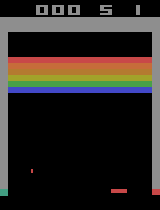

In [12]:
# Loads the saved model -> update this path if using the pre-trained model from GitHub if needed
model = PPO.load("/content/drive/MyDrive/breakout_ppo")

# Create a fresh evaluation environment (1 env, no fixed seed for varied gameplay)
eval_env = make_atari_env("ALE/Breakout-v5", n_envs=1)
eval_env = VecFrameStack(eval_env, n_stack=4)

obs = eval_env.reset()
deploy_frames = 500 # Amount of frames the model is allowed to play for until forced reset
frames = []
total_reward = 0

for _ in range(deploy_frames):
    # deterministic=True -> always pick the highest confidence action
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)
    frame = eval_env.render()
    frames.append(frame)
    total_reward += reward[0]
    if done[0]:
        obs = eval_env.reset() # On game over, reset instead of stopping so we record more gameplay

eval_env.close()

imageio.mimsave("breakout_demo.gif", frames, fps=10)
print(f"Total reward: {total_reward}")
Image("breakout_demo.gif", width=400)